In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from models import Encoder, Decoder, Discriminator
from loss_functions import *
import torch.optim as optim

import matplotlib.pyplot as plt

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [3]:
class ColorMNIST(Dataset):
    """
    MNIST with a single binary attribute:
      0 -> RED
      1 -> GREEN

    Returns:
      x : (3, 32, 32)
      y_onehot : (2,)  for Decoder
      y_scalar : (1,)  for Discriminator
    """

    def __init__(self, root, train=True, download=False, seed=0):
        self.base = datasets.MNIST(
            root=root,
            train=train,
            download=download,
            transform=transforms.Compose([
                transforms.Resize((32, 32)),
                transforms.ToTensor(),  # (1,32,32)
            ])
        )

        n = len(self.base)
        g = torch.Generator().manual_seed(seed)
        perm = torch.randperm(n, generator=g)

        # 50 / 50 split
        attr = torch.zeros(n, dtype=torch.long)
        attr[perm[: n // 2]] = 1
        self.attr = attr  # (n,)

        # colors
        self.red_rgb   = torch.tensor([1.0, 0.1, 0.1]).view(3, 1, 1)
        self.green_rgb = torch.tensor([0.1, 1.0, 0.1]).view(3, 1, 1)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, digit = self.base[idx]     # x: (1,32,32)
        a = self.attr[idx].item()     # 0 or 1

        # grayscale → RGB
        x = x.repeat(3, 1, 1)

        # colorize
        if a == 1:
            x = x * self.green_rgb
        else:
            x = x * self.red_rgb

        x = x.clamp(0, 1)

        # ---- labels ----
        y_scalar = torch.tensor([a], dtype=torch.float32)   # (1,)
        y_onehot = torch.zeros(2)
        y_onehot[a] = 1.0                                   # (2,)

        return x, y_onehot, y_scalar, digit


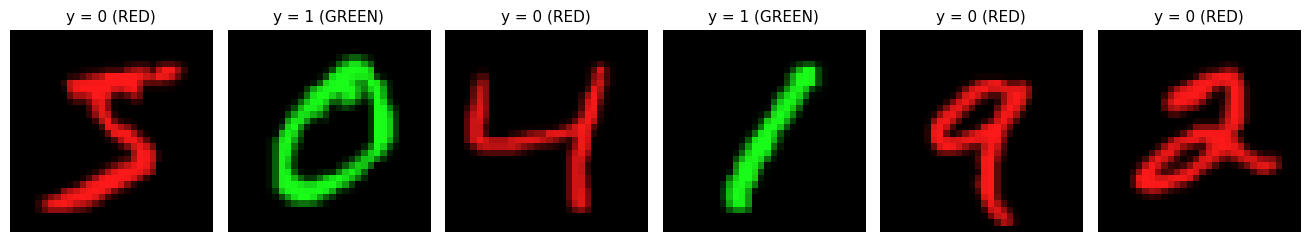

In [14]:
''' This cell prints a few examples of the colored MNIST dataset '''

def show_colormnist_examples(dataset, n=6, start_idx=0):
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.5))

    for i, ax in enumerate(axes):
        x, y_oh, y_sc, d = dataset[start_idx + i]

        y_val = int(y_sc.item())
        color_name = "GREEN" if y_val == 1 else "RED"

        ax.imshow(x.permute(1, 2, 0))
        ax.set_title(f"y = {y_val} ({color_name})", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

DATA_ROOT = "shared/fader_network_26/datasets"

ds = ColorMNIST(
    root=DATA_ROOT,
    train=True,
    download=False
)

show_colormnist_examples(ds, n=6)

In [5]:
@torch.no_grad()
def show_fader_two_blocks(
    encoder,
    decoder,
    dataset,
    device,
    idx_red_to_green,
    idx_green_to_red,
    n_steps=9,
    epoch=None,
):
    """
    Block 1: RED -> GREEN  (t: 0 -> 1)
    Block 2: GREEN -> RED  (t: 1 -> 0)

    Each row: Original | Recon | t progression (only one direction)
    """

    encoder.eval(); decoder.eval()

    ts_up = torch.linspace(0, 1, n_steps)         # 0 -> 1
    ts_down = torch.flip(ts_up, dims=[0])         # 1 -> 0

    def make_rows(indices, ts, block_title):
        n_rows = len(indices)
        n_cols = 2 + len(ts)  # Original + Recon + steps

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(1.45*n_cols, 2.3*n_rows),
            dpi=120
        )
        if n_rows == 1:
            axes = axes.reshape(1, -1)

        for r, idx in enumerate(indices):
            x, y_onehot, y_bin, _ = dataset[idx]
            x = x.unsqueeze(0).to(device)
            y_onehot = y_onehot.unsqueeze(0).to(device)

            z = encoder(x)
            x_rec = decoder(z, y_onehot)[0]

            # Original
            axes[r, 0].imshow(x[0].cpu().permute(1,2,0).clamp(0,1))
            axes[r, 0].axis("off")
            # Recon
            axes[r, 1].imshow(x_rec.cpu().permute(1,2,0).clamp(0,1))
            axes[r, 1].axis("off")

            for c, t in enumerate(ts):
                y_soft = torch.tensor([[1.0 - float(t), float(t)]], device=device)  # [1-t, t]
                out = decoder(z, y_soft)[0]
                axes[r, c+2].imshow(out.cpu().permute(1,2,0).clamp(0,1))
                axes[r, c+2].axis("off")

            yval = int(y_bin.item())
            axes[r, 0].set_ylabel(f"idx {idx}\ny={yval}", rotation=0, labelpad=35, fontsize=10)

        # headers
        if n_rows > 0:
            axes[0, 0].set_title("Original", fontsize=10)
            axes[0, 1].set_title("Recon", fontsize=10)
            for c, t in enumerate(ts):
                axes[0, c+2].set_title(f"{float(t):.2f}", fontsize=8)

        title = f"{block_title} — epoch {epoch}" if epoch is not None else block_title
        plt.suptitle(title, fontsize=13)
        plt.tight_layout()
        plt.show()

    make_rows(idx_red_to_green, ts_up, "RED → GREEN (0→1)")
    make_rows(idx_green_to_red, ts_down, "GREEN → RED (1→0)")


In [6]:


def train_mnist_fader(
    train_loader,
    epochs=10,
    lr=2e-4,
    lambda_E=1.0,
    device=None,
    display_every=1,
):
    NUM_FADER_EXAMPLES = 4
    FIXED_INDICES = torch.randperm(len(train_loader.dataset))[:NUM_FADER_EXAMPLES].tolist()
    print("Fixed indices:", FIXED_INDICES)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Models
    encoder = Encoder("mnist").to(device)
    decoder = Decoder("mnist", num_attributes=1).to(device)          # 1 binary attribute => one-hot size 2
    discriminator = Discriminator(num_attributes=1).to(device)

    # Optims
    opt_E = optim.Adam(encoder.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_Dec = optim.Adam(decoder.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    rec_history = []
    adv_history = []
    disc_history = []


    for epoch in range(1, epochs + 1):
        encoder.train(); decoder.train(); discriminator.train()

        rec_sum = 0.0
        d_sum = 0.0
        adv_sum = 0.0
        n_batches = 0

        for batch in train_loader:
            x, y_onehot, y_bin, digit = batch
            x = x.to(device)                       # (B,3,32,32)
            y_onehot = y_onehot.to(device)         # (B,2)
            y_bin = y_bin.to(device)               # (B,1) float/0-1

            # -------------------
            # (1) Update D
            # -------------------
            opt_D.zero_grad(set_to_none=True)

            loss_D = discriminator_loss(encoder, discriminator, x, y_bin)  # expects (B,1)
            loss_D.backward()
            opt_D.step()

            # -------------------
            # (2) Update Encoder + Decoder (freeze D)
            # -------------------
            for p in discriminator.parameters():
                p.requires_grad_(False)

            opt_E.zero_grad(set_to_none=True)
            opt_Dec.zero_grad(set_to_none=True)

            loss_ED, parts = adversarial_loss(
                encoder=encoder,
                decoder=decoder,
                discriminator=discriminator,
                x=x,
                y_onehot=y_onehot,
                y_bin=y_bin,
                lambda_E=lambda_E,
                reconstruction_loss_fn=reconstruction_loss,
            )
            loss_ED.backward()
            opt_E.step()
            opt_Dec.step()

            for p in discriminator.parameters():
                p.requires_grad_(True)

            rec_sum += float(parts["recon"])
            adv_sum += float(parts["adv"])
            d_sum += float(loss_D.detach())
            n_batches += 1

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"recon={rec_sum/n_batches:.4f} | "
            f"adv={adv_sum/n_batches:.4f} | "
            f"D={d_sum/n_batches:.4f}"
        )

        rec_history.append(rec_sum / n_batches)
        adv_history.append(adv_sum / n_batches)
        disc_history.append(d_sum / n_batches)


        # per-epoch display: original / recon / fader
        show_fader_two_blocks(
            encoder=encoder,
            decoder=decoder,
            dataset=train_loader.dataset,
            device=device,
            idx_red_to_green=red_idx,
            idx_green_to_red=green_idx,
            n_steps=9,
            epoch=epoch
        )

    return encoder, decoder, discriminator, rec_history, adv_history, disc_history

red examples: [25139, 15309]
green examples: [36044, 10678]
Starting training
Fixed indices: [27953, 38120, 7367, 44667]
Epoch 001/10 | recon=0.0179 | adv=1.0533 | D=0.7046


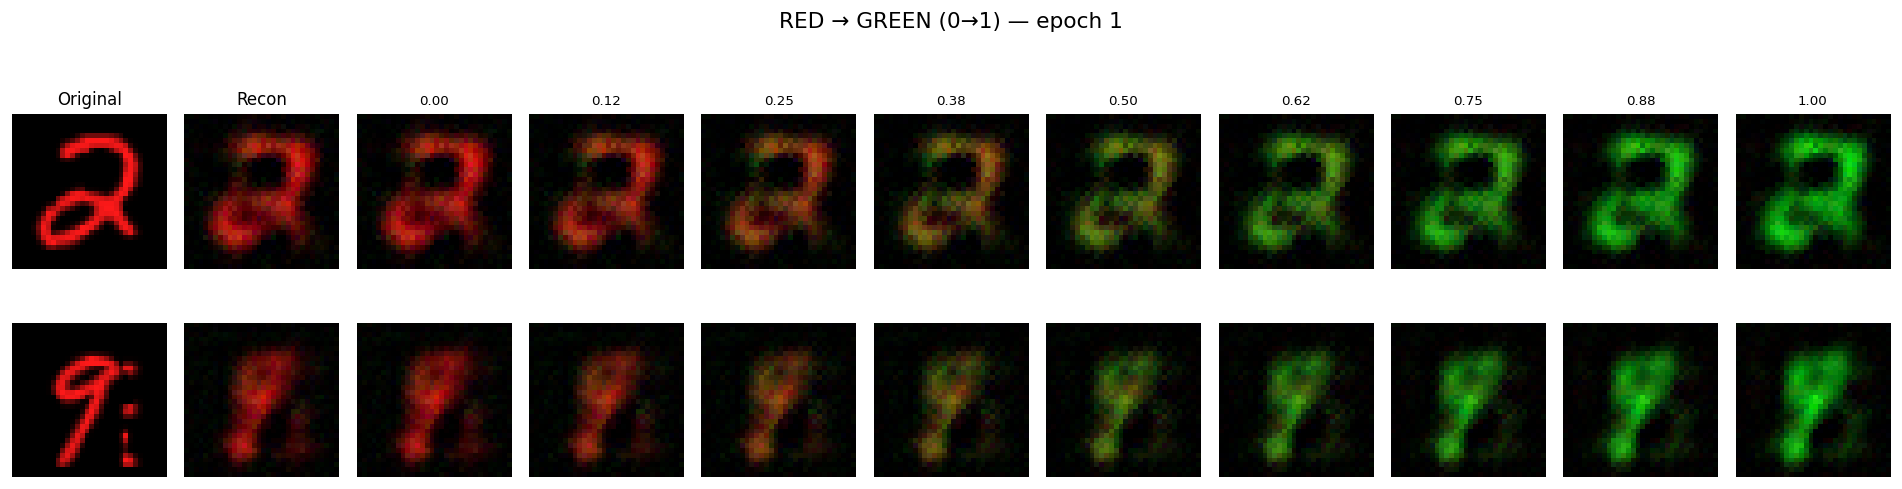

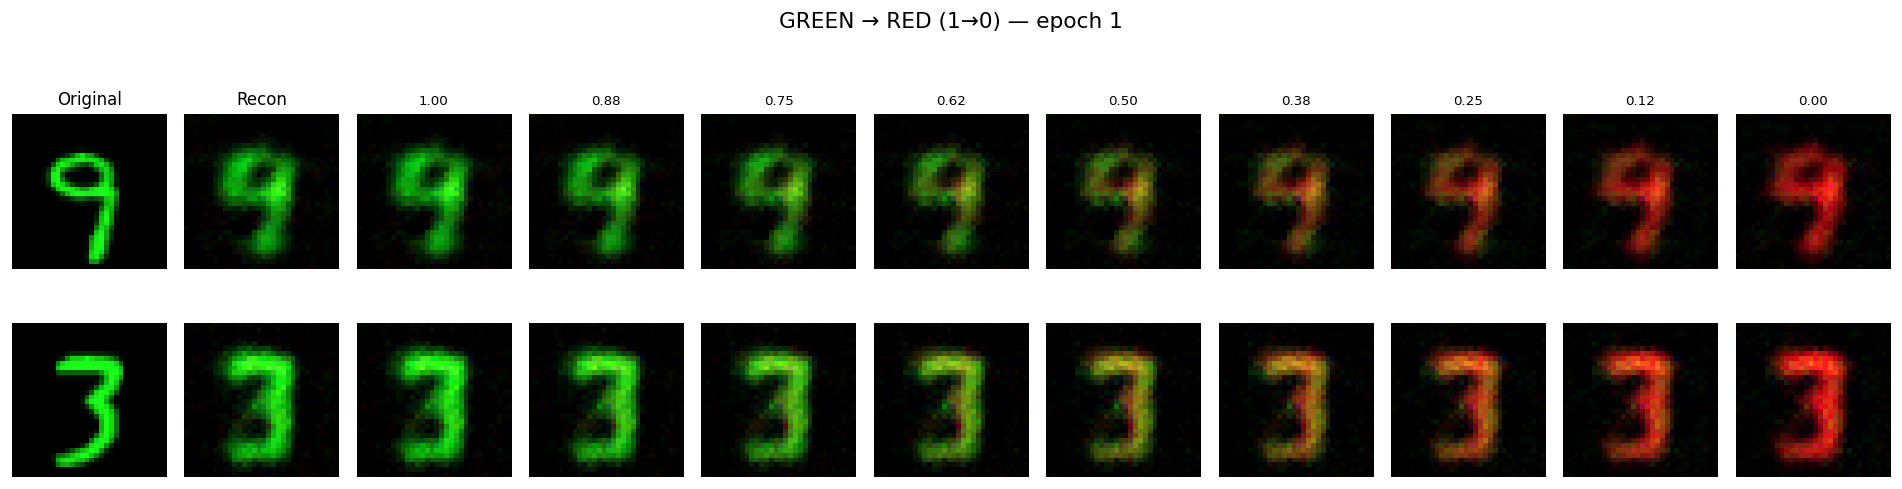

Epoch 002/10 | recon=0.0065 | adv=0.7124 | D=0.6908


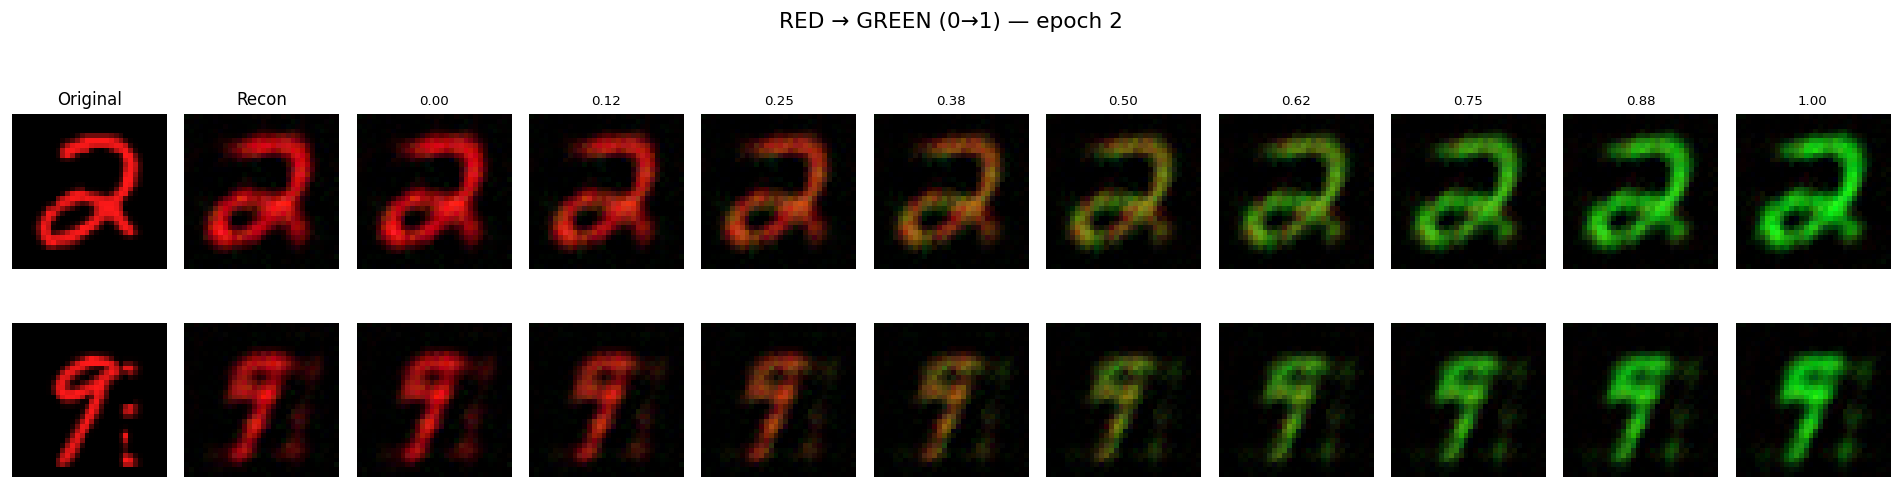

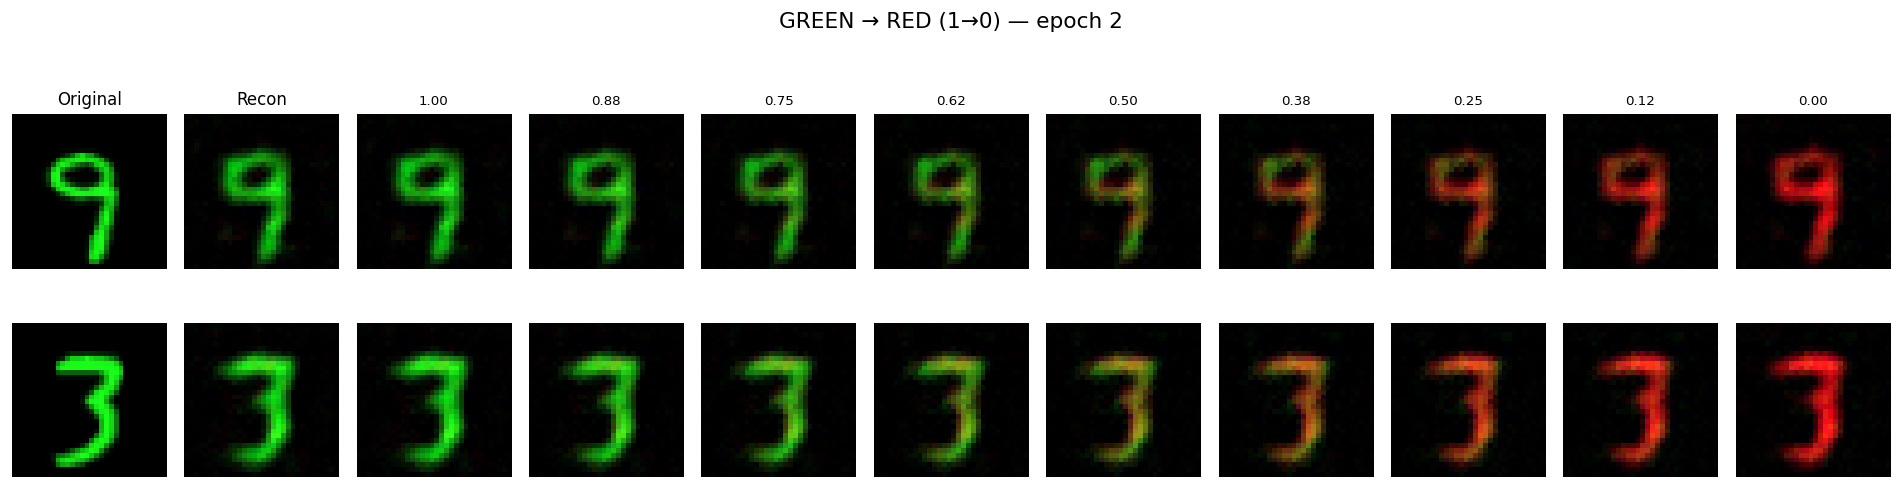

Epoch 003/10 | recon=0.0044 | adv=0.6980 | D=0.6942


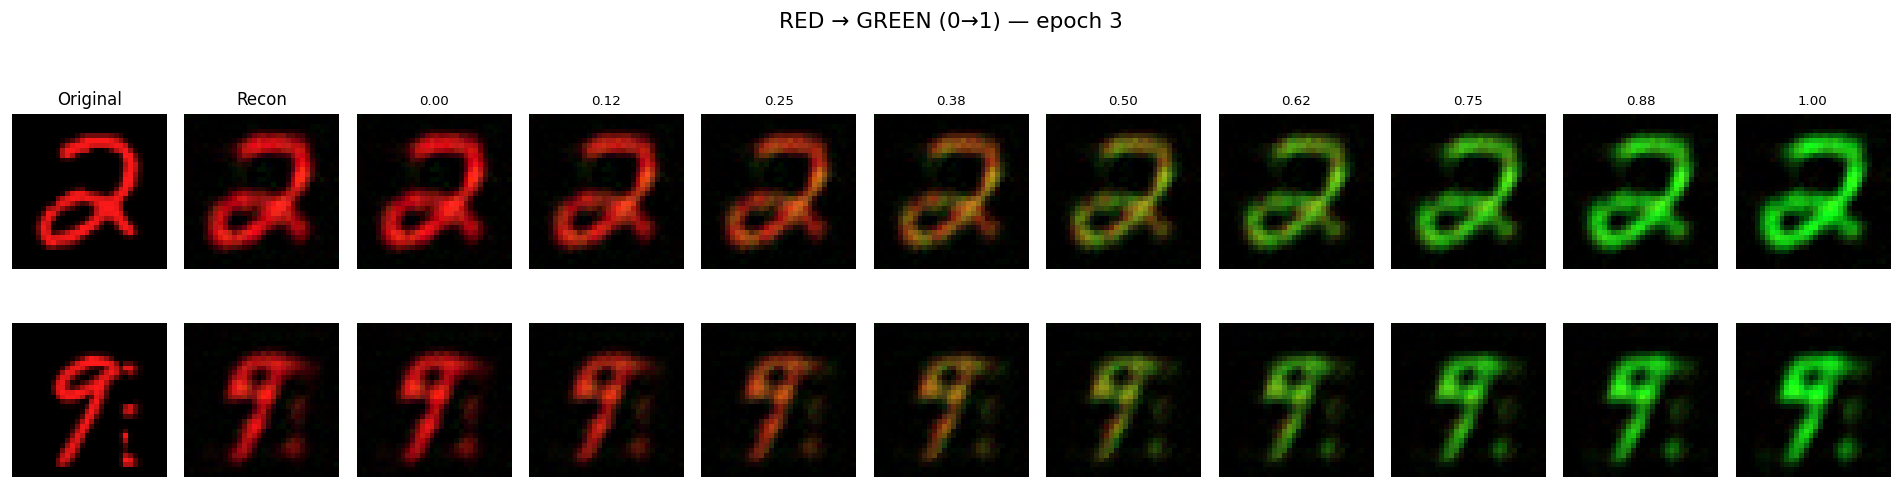

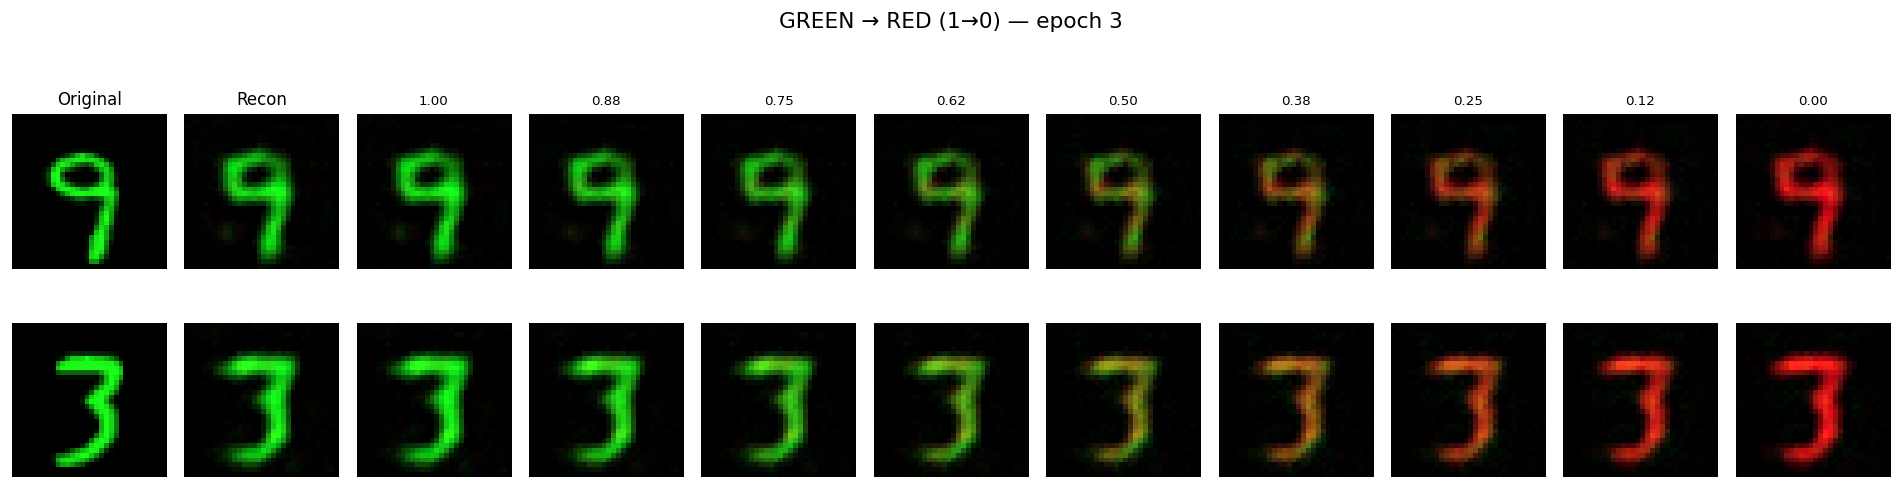

Epoch 004/10 | recon=0.0035 | adv=0.6966 | D=0.6940


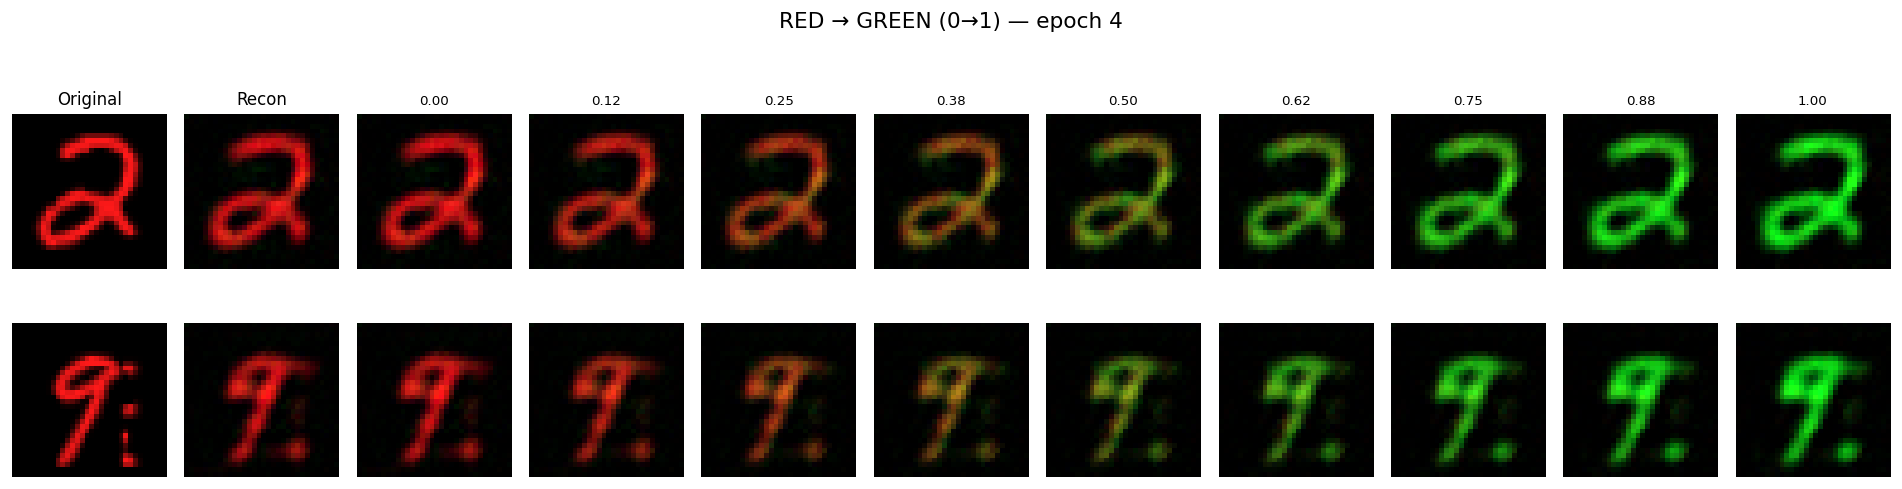

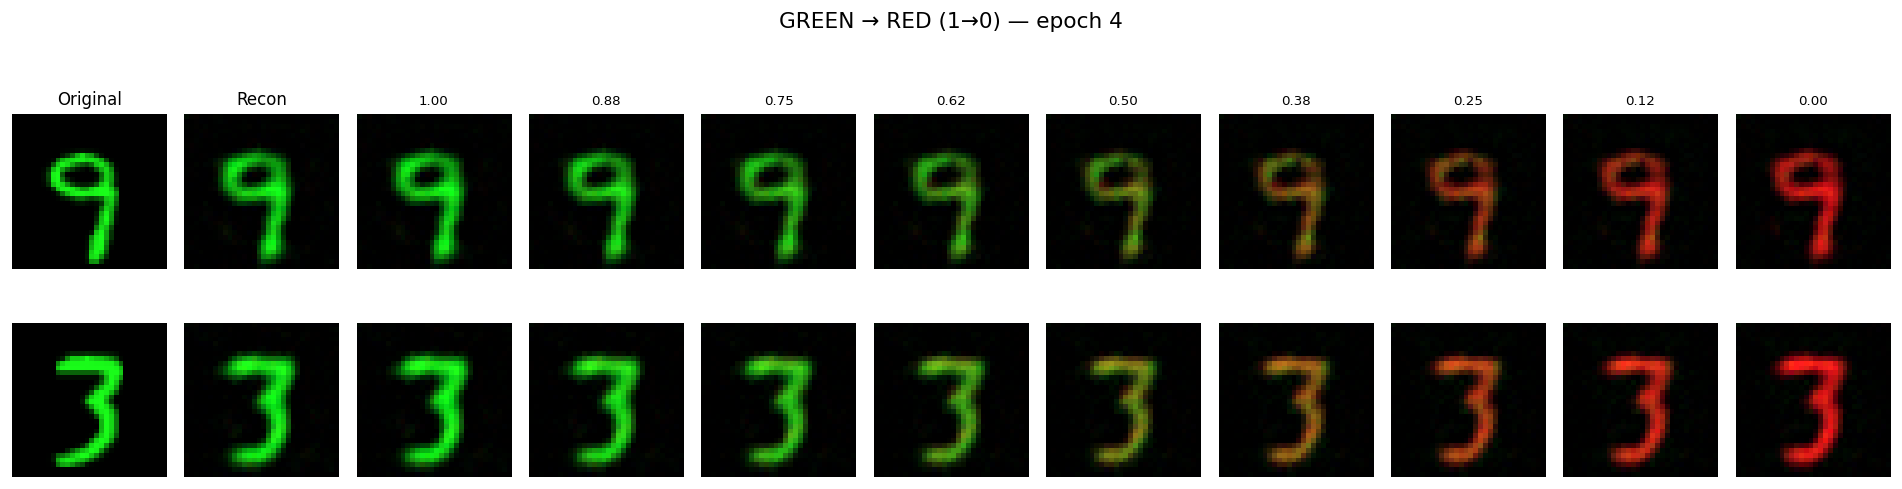

Epoch 005/10 | recon=0.0030 | adv=0.6955 | D=0.6937


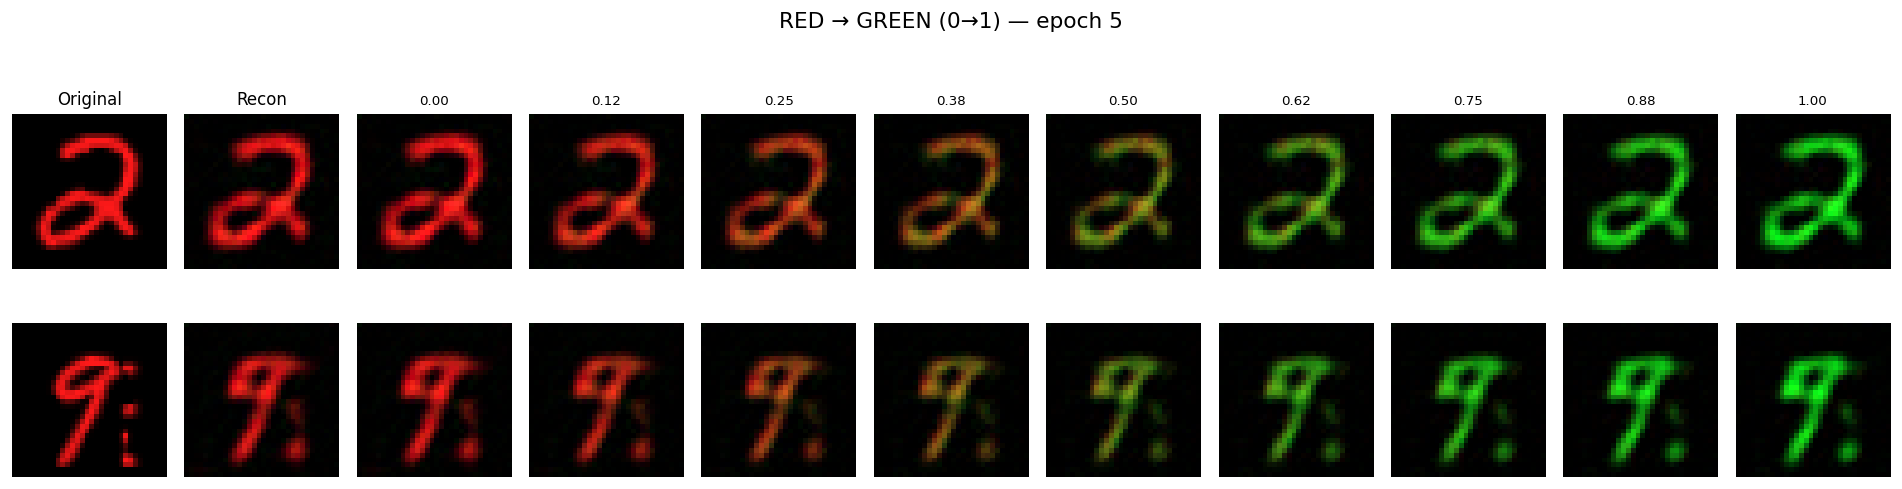

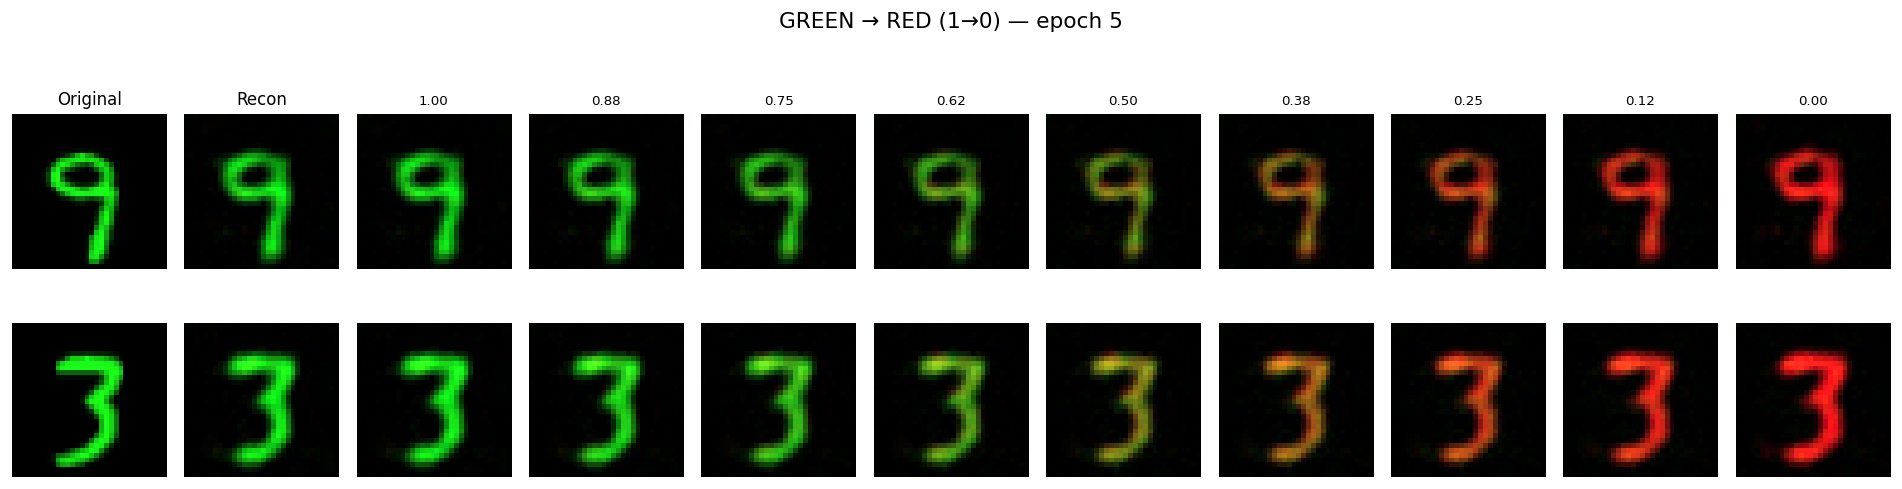

Epoch 006/10 | recon=0.0026 | adv=0.6948 | D=0.6934


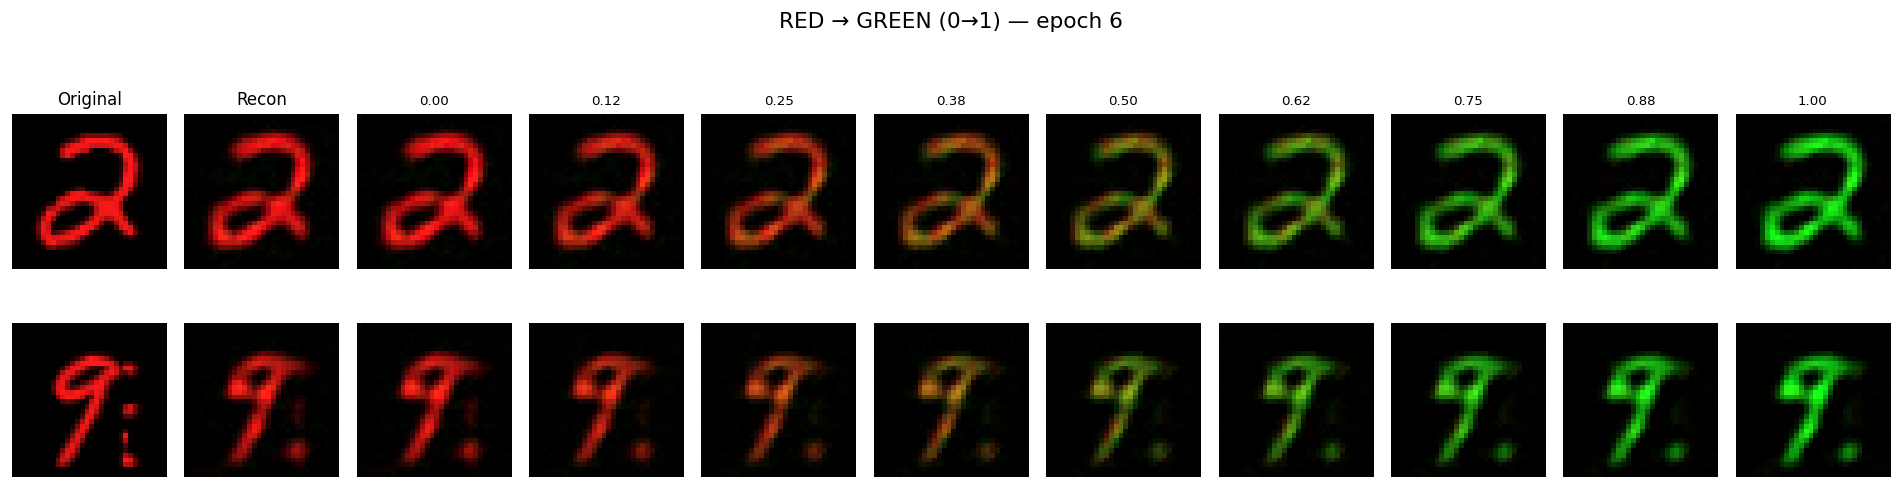

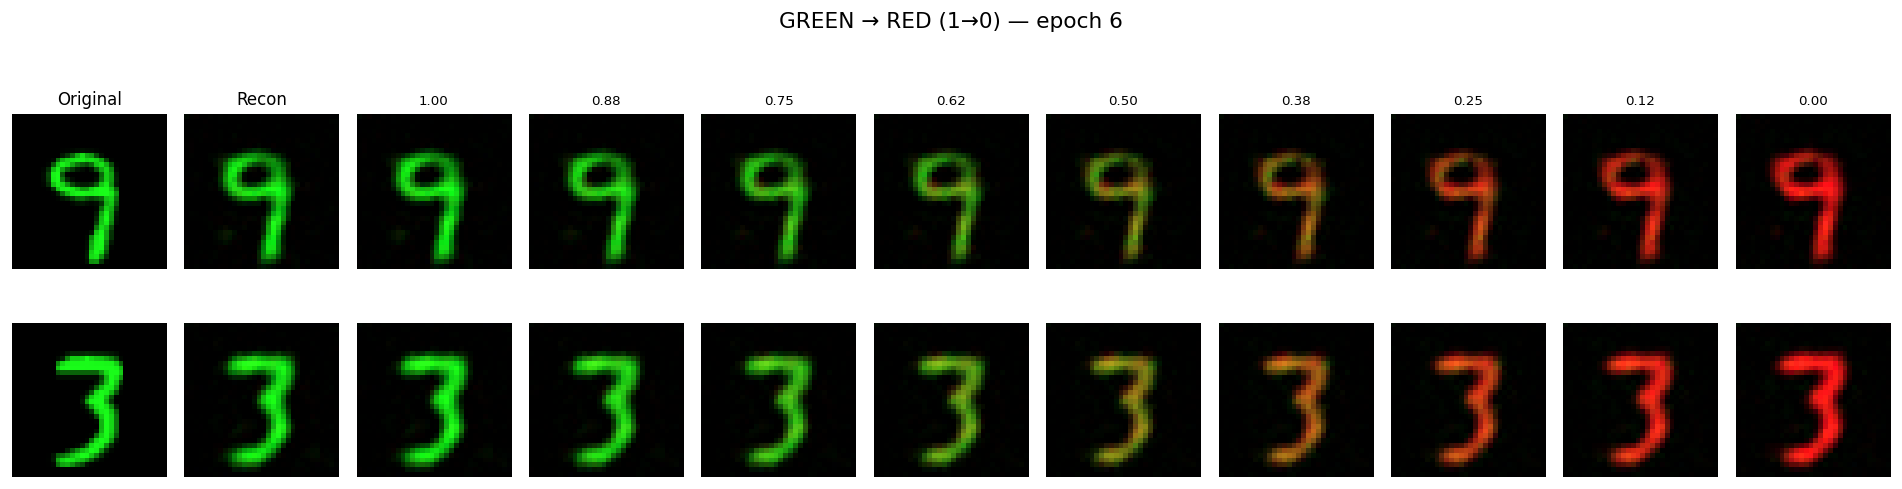

Epoch 007/10 | recon=0.0023 | adv=0.6942 | D=0.6934


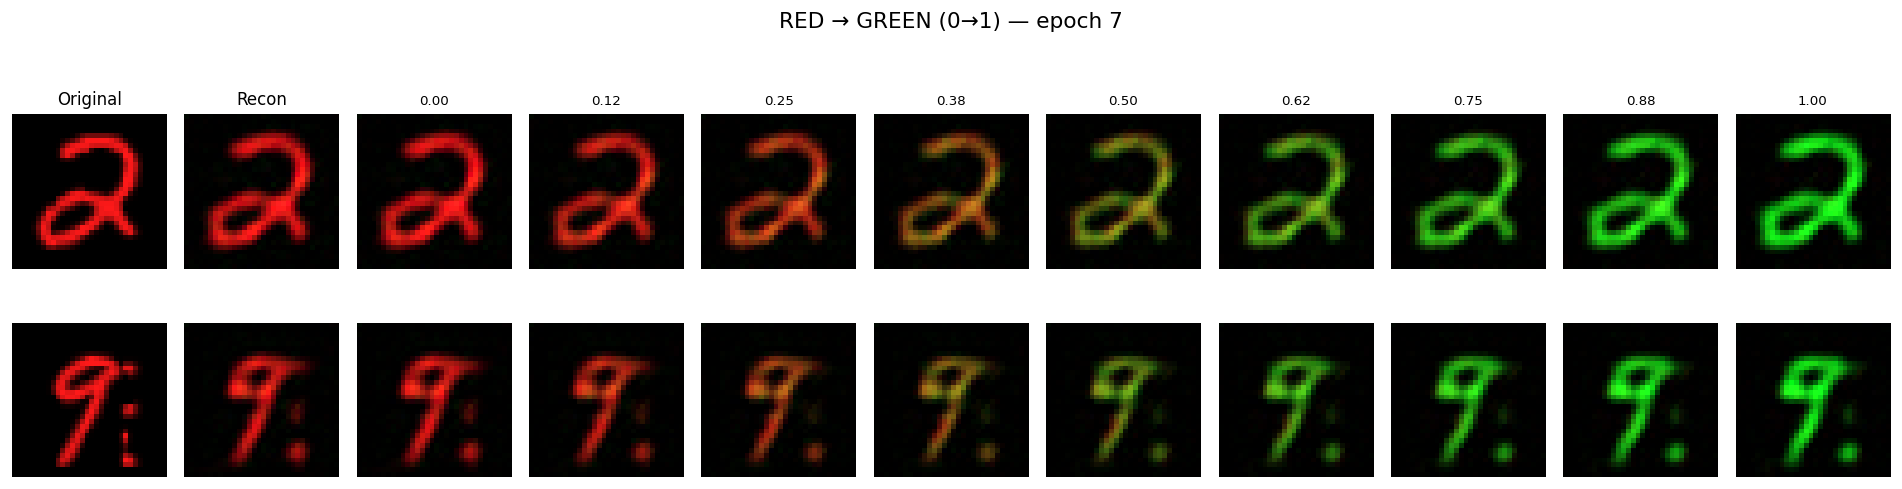

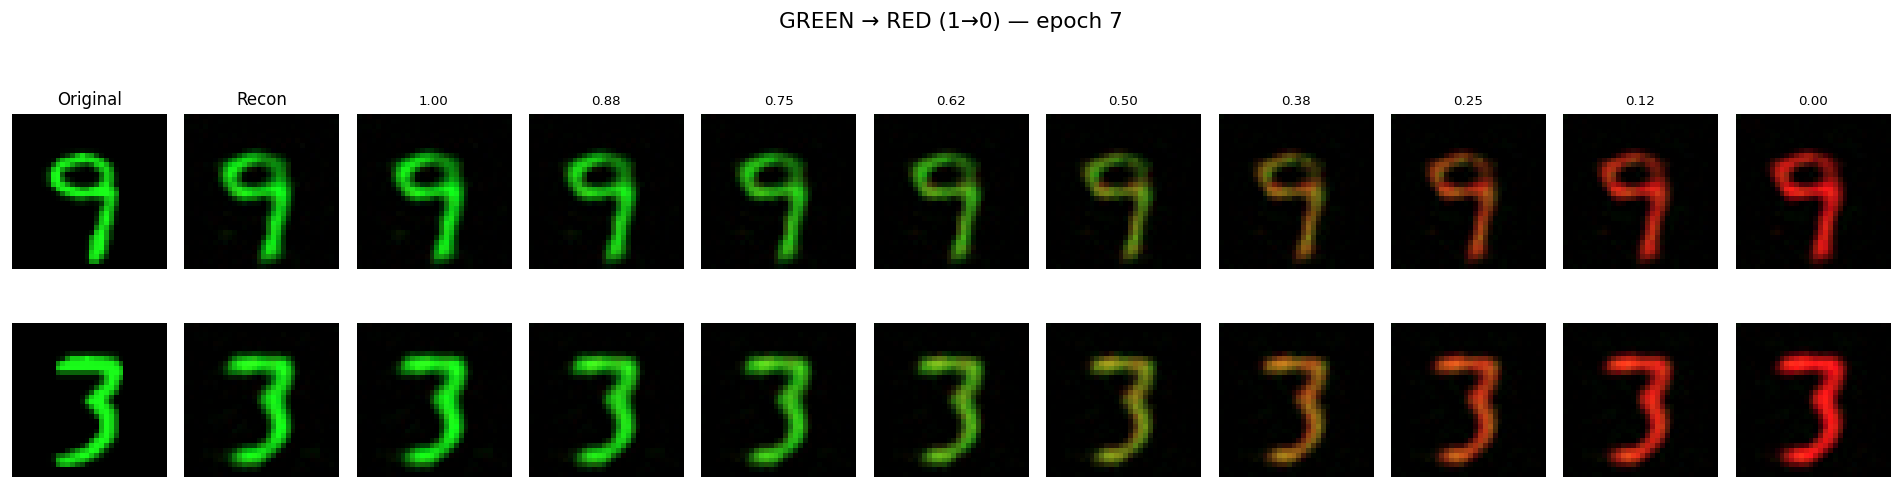

Epoch 008/10 | recon=0.0021 | adv=0.6942 | D=0.6935


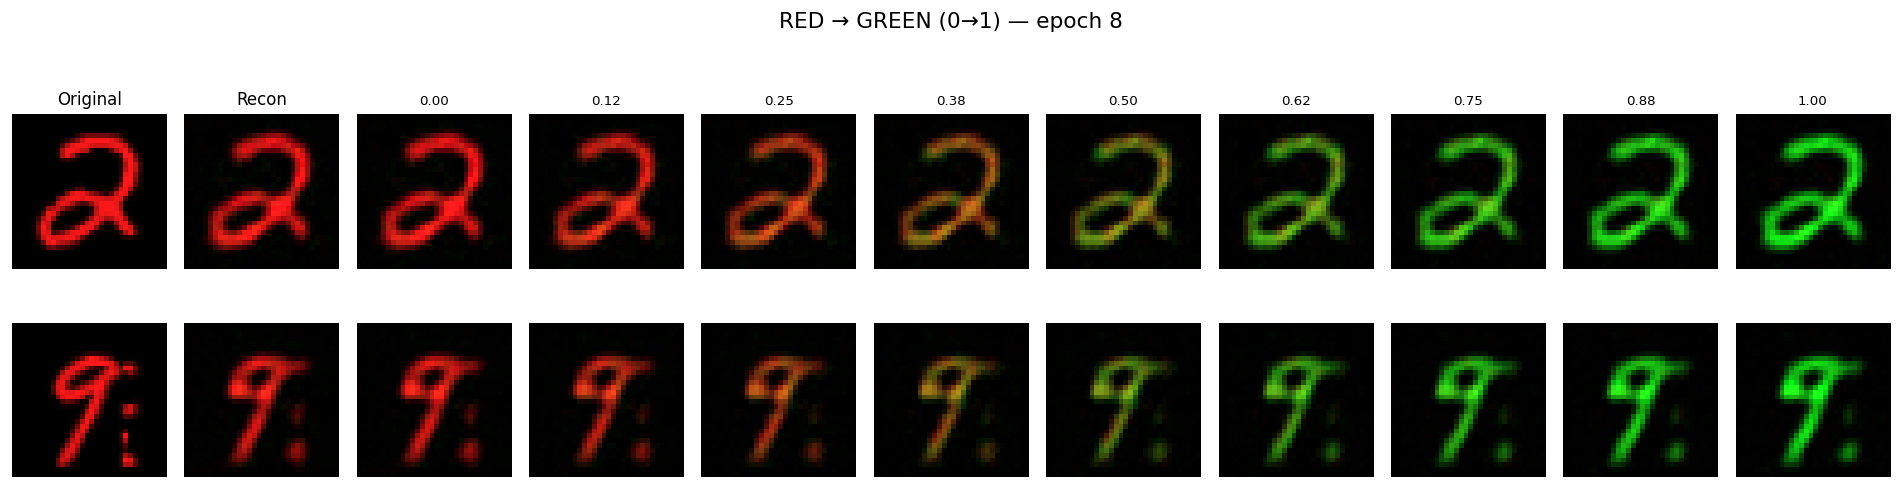

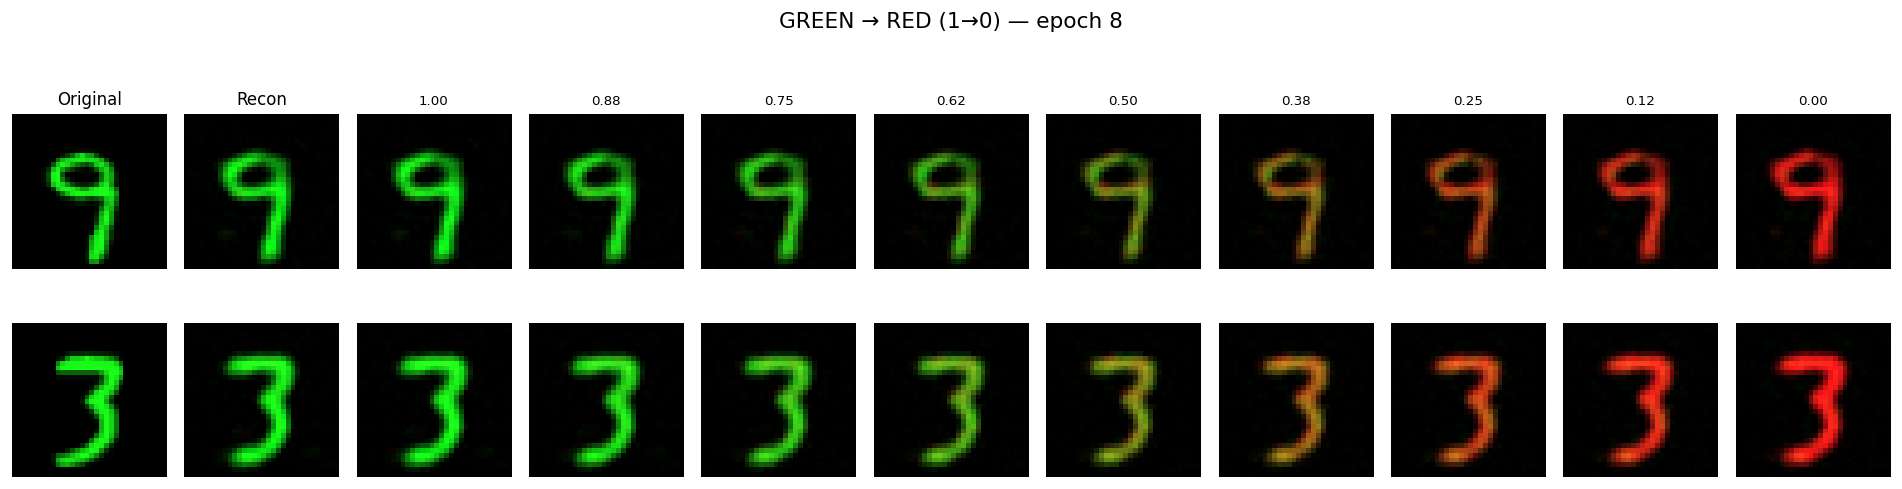

Epoch 009/10 | recon=0.0019 | adv=0.6942 | D=0.6935


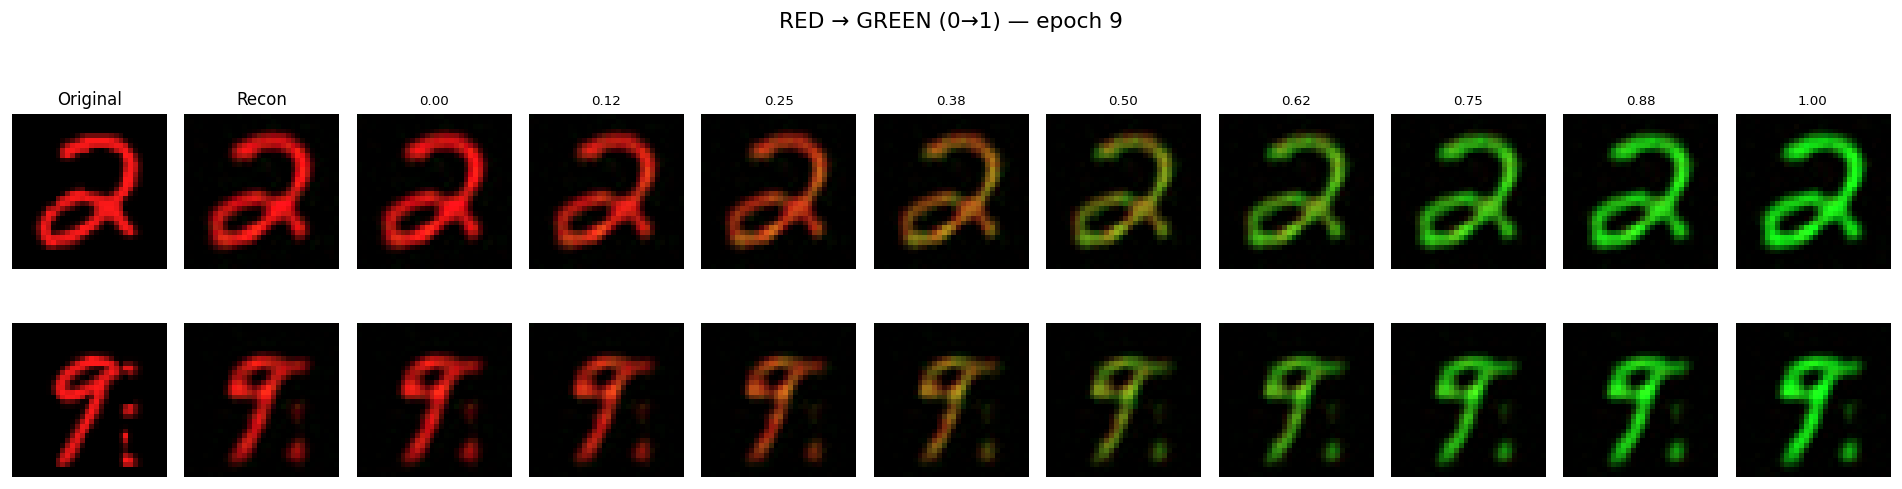

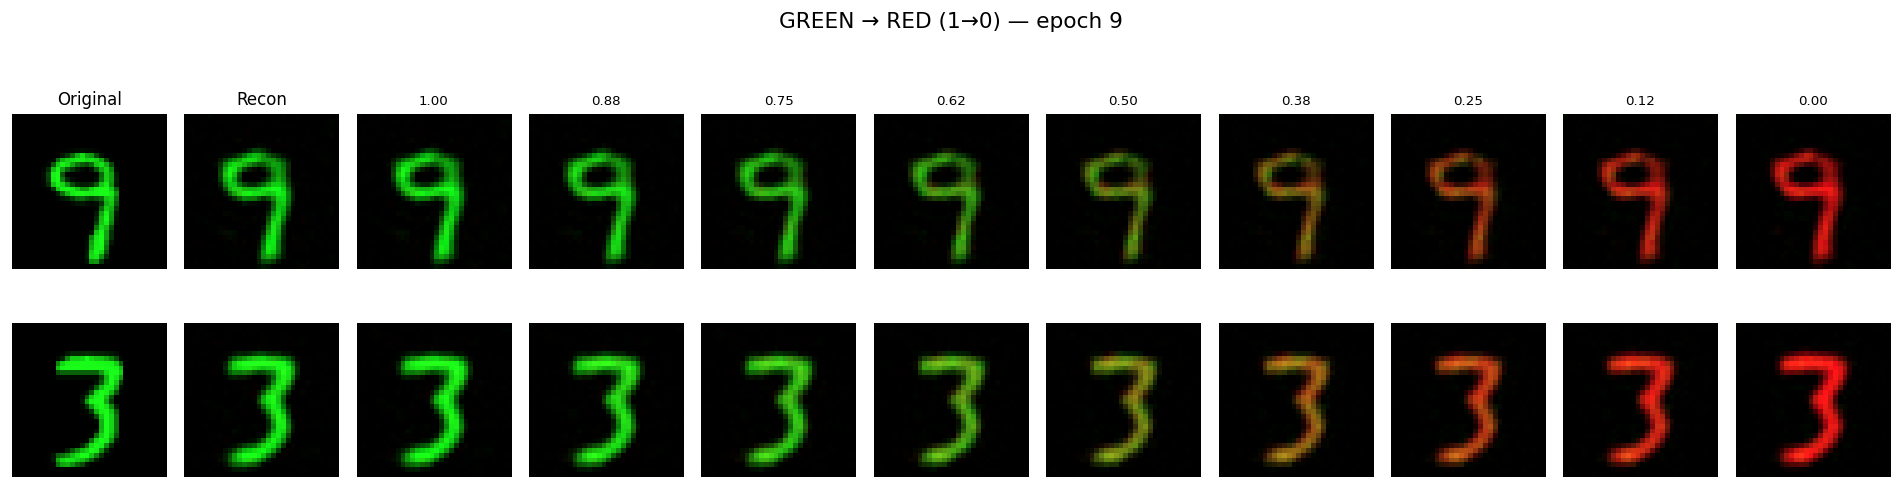

Epoch 010/10 | recon=0.0018 | adv=0.6941 | D=0.6934


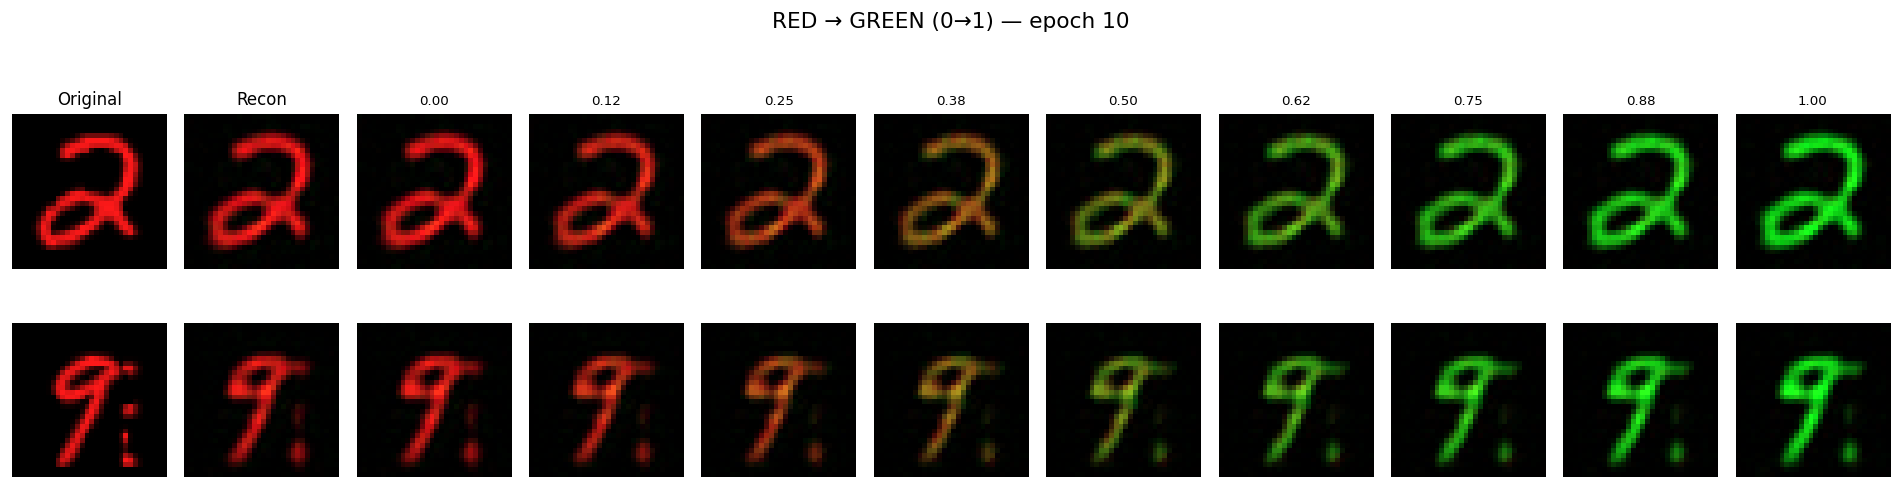

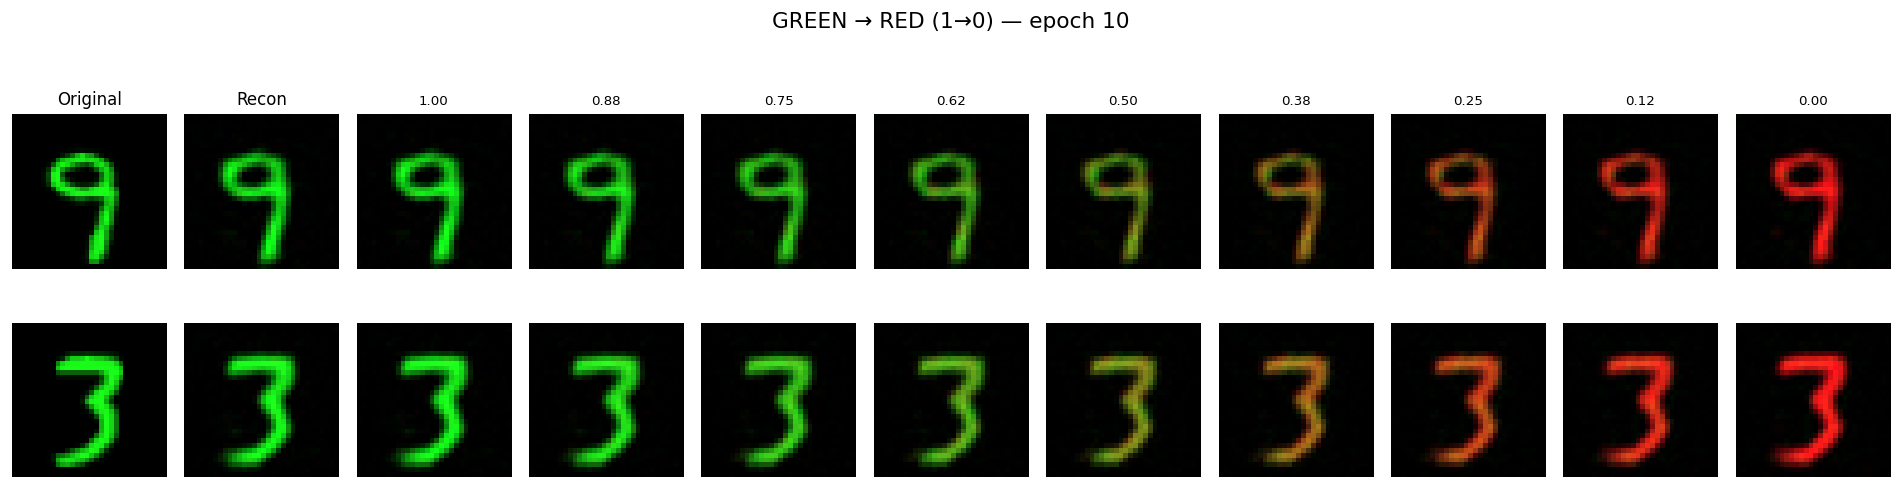

In [8]:
def pick_indices_by_color(dataset, n_each=4):
    red_idx, green_idx = [], []
    for i in torch.randperm(len(dataset)).tolist():
        _, _, y_bin, _ = dataset[i]
        if int(y_bin.item()) == 0 and len(red_idx) < n_each:
            red_idx.append(i)
        if int(y_bin.item()) == 1 and len(green_idx) < n_each:
            green_idx.append(i)
        if len(red_idx) == n_each and len(green_idx) == n_each:
            break
    return red_idx, green_idx



train_ds = ColorMNIST(
    root=DATA_ROOT,
    train=True,
    download=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
red_idx, green_idx = pick_indices_by_color(train_loader.dataset, n_each=2)
print("red examples:", red_idx)
print("green examples:", green_idx)

print("Starting training")
encoder, decoder, disc, rec_loss, adv_loss, disc_loss = train_mnist_fader(
    train_loader=train_loader,
    epochs=10,
    lr=2e-4,
    lambda_E=1.0,
    display_every=1
)

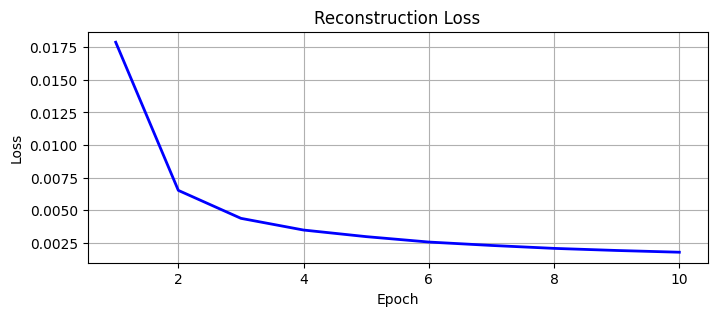

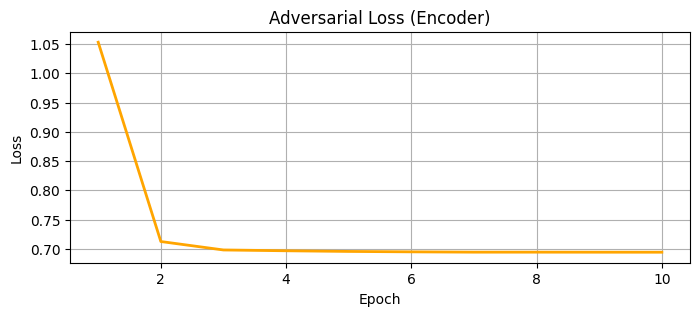

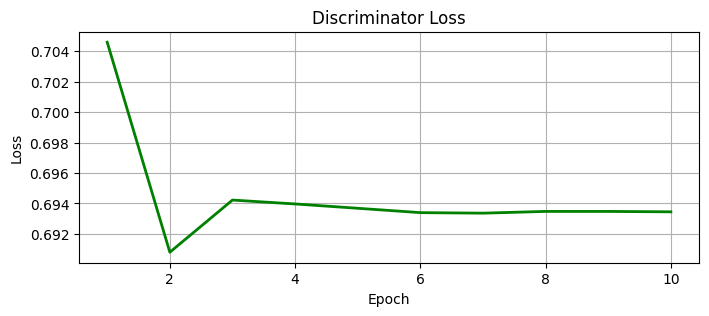

In [13]:
import matplotlib.pyplot as plt

def plot_fader_losses(rec_losses, adv_losses, disc_losses):
    epochs = range(1, len(rec_losses) + 1)

    # --- Reconstruction ---
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, rec_losses, linewidth=2, color='blue')
    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    # --- Adversarial (Encoder) ---
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, adv_losses, linewidth=2, color='orange')
    plt.title("Adversarial Loss (Encoder)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    # --- Discriminator ---
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, disc_losses, linewidth=2, color='green')
    plt.title("Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


plot_fader_losses(rec_loss, adv_loss, disc_loss)
